# 01 — Foundations
**Goal:** Understand how matplotlib is structured before writing a single chart.

## The mental model
Matplotlib has two levels:
- **Figure** → the whole canvas (like a blank sheet of paper)
- **Axes** → one plot inside the figure (you can have many)

Everything you draw lives inside an `Axes`, not directly on the `Figure`.

```
Figure
└── Axes
    ├── x-axis
    ├── y-axis
    ├── title
    ├── lines / bars / scatter
    └── legend
```

In [2]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import matplotlib.pyplot as plt

print('matplotlib version:', plt.matplotlib.__version__)

matplotlib version: 3.11.0


## 1. The anatomy of a Figure

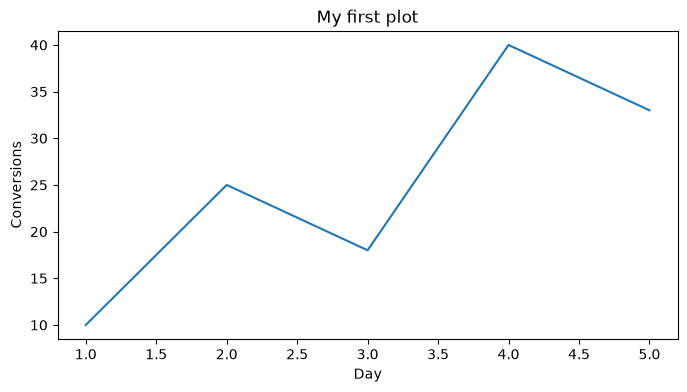

In [3]:
# fig  → the whole canvas
# ax   → one plot inside the canvas
# This is the pattern you'll use 90% of the time
fig, ax = plt.subplots(figsize=(8, 4))

# Simple line — x values, y values
x = [1, 2, 3, 4, 5]
y = [10, 25, 18, 40, 33]

ax.plot(x, y)

# Labels and title always go on the Axes (ax), not the Figure (fig)
ax.set_title('My first plot')
ax.set_xlabel('Day')
ax.set_ylabel('Conversions')

plt.show()

## 2. Figure size and resolution
`figsize=(width, height)` is in **inches**.  
`dpi` (dots per inch) controls sharpness — higher = sharper but heavier.

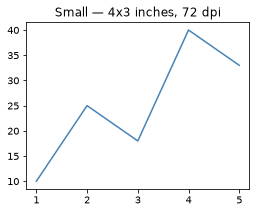

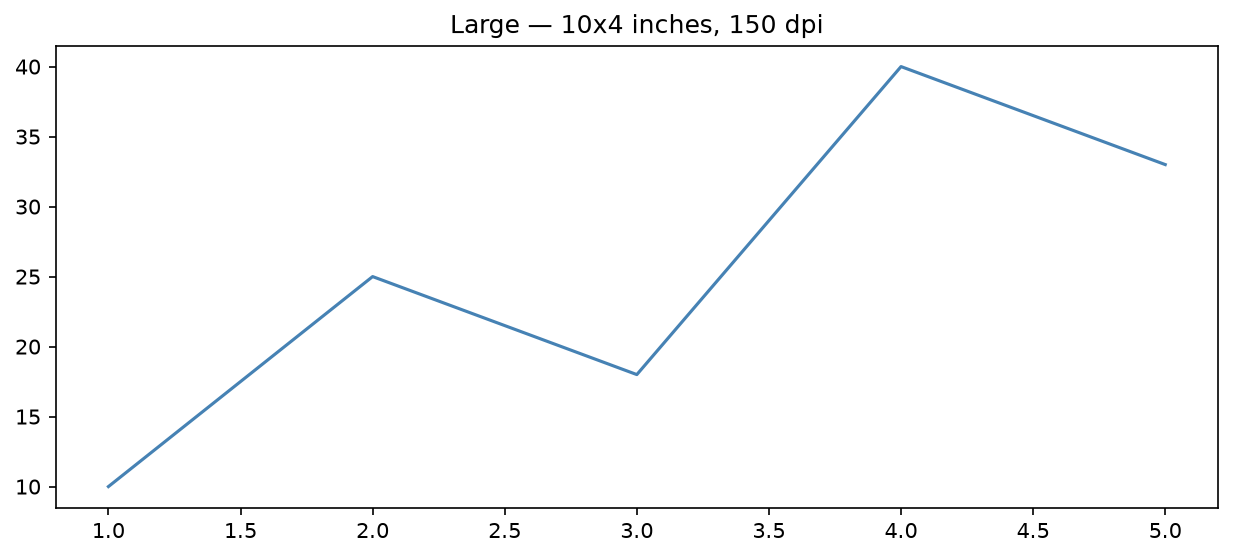

In [4]:
# Small figure, low resolution (quick exploration)
fig, ax = plt.subplots(figsize=(4, 3), dpi=72)
ax.plot(x, y, color='steelblue')
ax.set_title('Small — 4x3 inches, 72 dpi')
plt.show()

# Larger figure, higher resolution (for reports)
fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.plot(x, y, color='steelblue')
ax.set_title('Large — 10x4 inches, 150 dpi')
plt.show()

## 3. The two APIs — pyplot vs OO
Matplotlib has two ways to write code. Always use the **OO (object-oriented)** style — it's explicit and works in dashboards, functions, and classes.

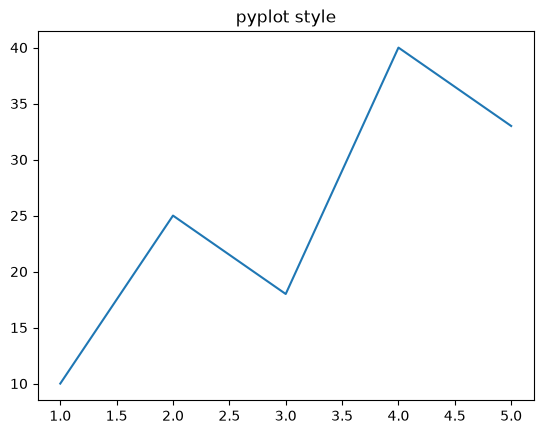

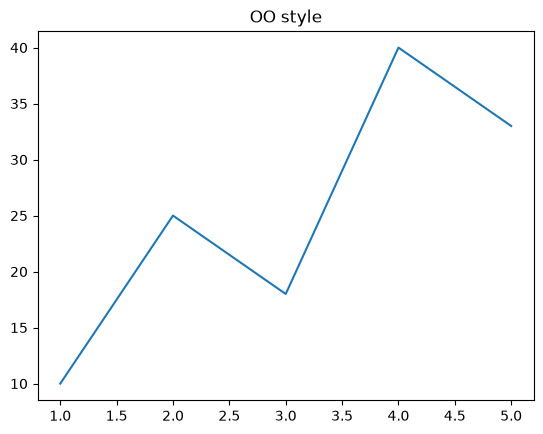

In [5]:
# ❌ pyplot style — implicit, matplotlib guesses which axes you mean
# Fine for quick scripts but breaks in functions and loops
plt.plot(x, y)
plt.title('pyplot style')
plt.show()

# ✅ OO style — explicit, you control exactly which axes you're editing
# Use this always
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('OO style')
plt.show()

## 4. Basic plot types

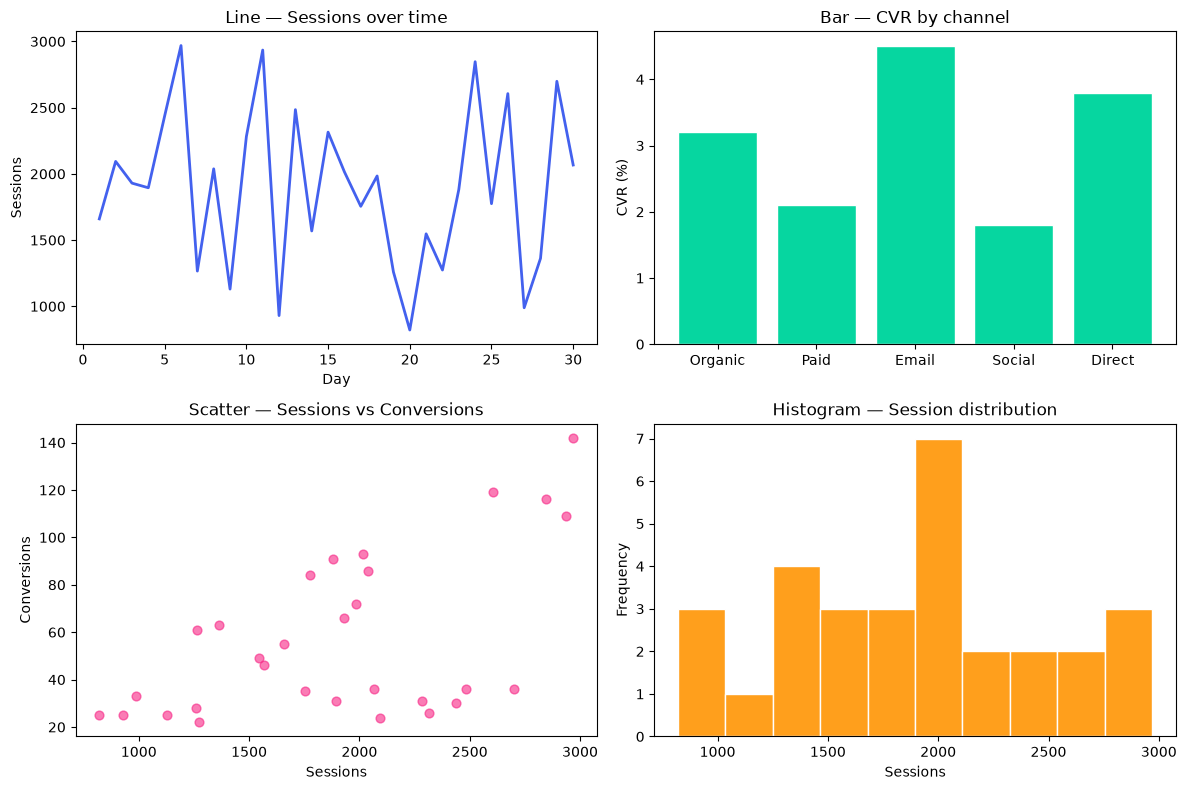

In [6]:
np.random.seed(42)
days = np.arange(1, 31)           # 30 days
sessions = np.random.randint(800, 3000, 30)
conversions = (sessions * np.random.uniform(0.01, 0.05, 30)).astype(int)
channels = ['Organic', 'Paid', 'Email', 'Social', 'Direct']
cvr = [3.2, 2.1, 4.5, 1.8, 3.8]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Line plot: good for trends over time ---
axes[0, 0].plot(days, sessions, color='#4361ee', linewidth=2)
axes[0, 0].set_title('Line — Sessions over time')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Sessions')

# --- Bar plot: good for comparing categories ---
axes[0, 1].bar(channels, cvr, color='#06d6a0', edgecolor='white')
axes[0, 1].set_title('Bar — CVR by channel')
axes[0, 1].set_ylabel('CVR (%)')

# --- Scatter plot: good for correlation between two metrics ---
axes[1, 0].scatter(sessions, conversions, alpha=0.6, color='#f72585', s=40)
axes[1, 0].set_title('Scatter — Sessions vs Conversions')
axes[1, 0].set_xlabel('Sessions')
axes[1, 0].set_ylabel('Conversions')

# --- Histogram: good for understanding distribution of a metric ---
axes[1, 1].hist(sessions, bins=10, color='#ff9f1c', edgecolor='white')
axes[1, 1].set_title('Histogram — Session distribution')
axes[1, 1].set_xlabel('Sessions')
axes[1, 1].set_ylabel('Frequency')

# tight_layout avoids overlapping titles and labels between subplots
plt.tight_layout()
plt.show()

## 5. Saving a figure
Always call `savefig` **before** `plt.show()` — after show, the figure is cleared.

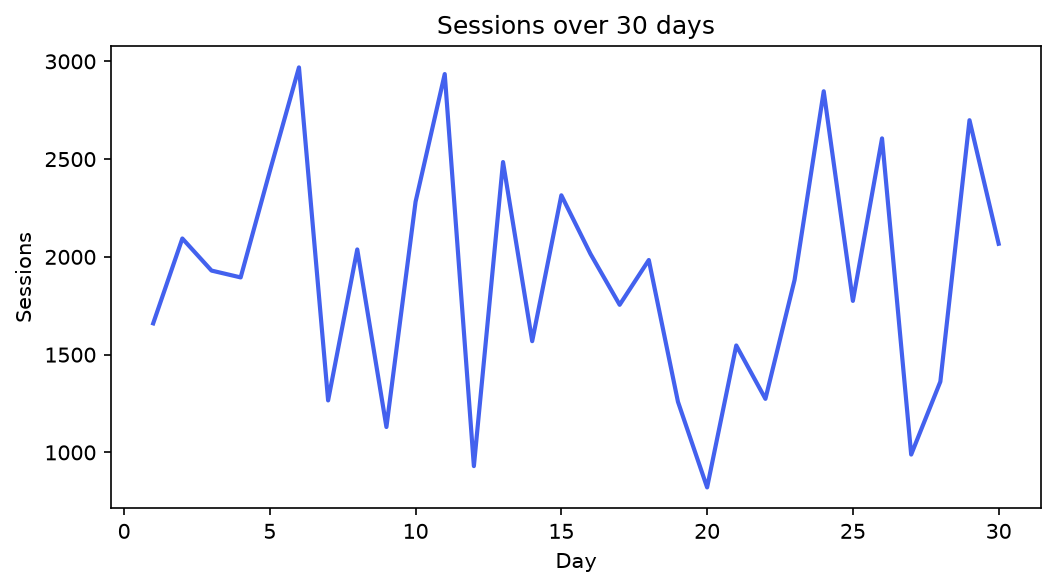

Saved to data/


In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(days, sessions, color='#4361ee', linewidth=2)
ax.set_title('Sessions over 30 days')
ax.set_xlabel('Day')
ax.set_ylabel('Sessions')

# bbox_inches='tight' removes extra whitespace around the figure
plt.savefig('data/01_foundations_example.png', dpi=150, bbox_inches='tight')
plt.savefig('data/01_foundations_example.pdf', bbox_inches='tight')

plt.show()
print('Saved to data/')

## Summary
| Concept | Key point |
|---|---|
| `Figure` | The full canvas |
| `Axes` | One plot inside the figure |
| `fig, ax = plt.subplots()` | The pattern to use always |
| OO style | Always prefer `ax.set_title()` over `plt.title()` |
| `figsize` | Width × height in inches |
| `dpi` | Resolution — 72 for screen, 150-300 for export |
| `savefig` | Call before `plt.show()` |

**Next:** `02_styling.ipynb` — making charts look professional.